# 1_a Data Overview

> Install note: this notebook needs `pandas`, `matplotlib`, and one parquet engine: `duckdb` (preferred) or `pyarrow`.

## Purpose

This notebook inspects the year-partitioned `feature_wo_messages` parquet dataset, confirms the available schema, limits analysis to records through the end of 2023, and builds a small monthly summary table for plotting.

Planned outputs:

- dataset structure and schema preview

- total users, messages, and tickers through 2023-12-31

- a monthly trend plot for messages, active users, and active tickers

- `figure_making/data/1_a_monthly_overview.csv`

In [1]:
from importlib import import_module
required_packages = ["pandas", "matplotlib"]
optional_engines = ["duckdb", "pyarrow"]
missing_required = []
for name in required_packages:
    try:
        import_module(name)
    except ImportError:
        missing_required.append(name)
available_engines = []
for name in optional_engines:
    try:
        import_module(name)
        available_engines.append(name)
    except ImportError:
        pass
missing_packages = missing_required.copy()
if not available_engines:
    missing_packages.append("duckdb or pyarrow")
if missing_packages:
    install_list = ", ".join(missing_packages)
    raise ImportError(
        "Missing packages: "
        f"{install_list}. Install them, then rerun this notebook."
    )
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ast import literal_eval
from collections import defaultdict
if "duckdb" in available_engines:
    import duckdb
    BACKEND = "duckdb"
else:
    import pyarrow.dataset as ds
    import pyarrow.parquet as pq
    BACKEND = "pyarrow"
plt.style.use("default")
pd.set_option("display.max_columns", 20)
print(f"Using parquet backend: {BACKEND}")

Using parquet backend: duckdb


In [2]:
DATA_ROOT = Path(r"C:\stocktwits_2026\parquet\feature_wo_messages")
OUTPUT_CSV = Path("figure_making/data/1_a_monthly_overview.csv")
DATE_CUTOFF = pd.Timestamp("2022-12-31 23:59:59+00:00")
END_EXCLUSIVE = pd.Timestamp("2024-01-01 00:00:00+00:00")
year_dirs = sorted(
    [path for path in DATA_ROOT.glob("year=*") if path.is_dir()],
    key=lambda path: int(path.name.split("=", 1)[1]),
)
selected_year_dirs = [
    path
    for path in year_dirs
    if int(path.name.split("=", 1)[1]) <= 2022
]
selected_files = [
    parquet_file
    for year_dir in selected_year_dirs
    for parquet_file in sorted(year_dir.glob("month=*/*.parquet"))
]
print(f"Dataset root: {DATA_ROOT}")
print(f"Available year partitions: {[path.name for path in year_dirs]}")
print(f"Selected year partitions (<= 2023): {[path.name for path in selected_year_dirs]}")
print(f"Selected parquet files: {len(selected_files):,}")
if not selected_files:
    raise FileNotFoundError("No parquet files were found for years up to and including 2023.")

Dataset root: C:\stocktwits_2026\parquet\feature_wo_messages
Available year partitions: ['year=2008', 'year=2009', 'year=2010', 'year=2011', 'year=2012', 'year=2013', 'year=2014', 'year=2015', 'year=2016', 'year=2017', 'year=2018', 'year=2019', 'year=2020', 'year=2021', 'year=2022', 'year=2023', 'year=2024']
Selected year partitions (<= 2023): ['year=2008', 'year=2009', 'year=2010', 'year=2011', 'year=2012', 'year=2013', 'year=2014', 'year=2015', 'year=2016', 'year=2017', 'year=2018', 'year=2019', 'year=2020', 'year=2021', 'year=2022']
Selected parquet files: 1,202


In [3]:
sample_file = selected_files[0]
print(f"Sample parquet file: {sample_file}")
print("First five selected files:")
for path in selected_files[:5]:
    print(f"  - {path}")
if BACKEND == "duckdb":
    con = duckdb.connect()
    schema_df = con.execute(
        f"DESCRIBE SELECT * FROM read_parquet('{sample_file.as_posix()}', hive_partitioning = true)"
    ).df()[["column_name", "column_type"]]
    schema_df = schema_df.rename(columns={"column_name": "column", "column_type": "dtype"})
else:
    parquet_schema = pq.ParquetFile(sample_file).schema_arrow
    schema_df = pd.DataFrame(
        {
            "column": parquet_schema.names,
            "dtype": [str(parquet_schema.field(name).type) for name in parquet_schema.names],
        }
    )
print(schema_df.to_string(index=False))
columns = set(schema_df["column"])
required_columns = {"message_id", "user_id", "created_at", "symbol_list"}
missing_schema_columns = sorted(required_columns - columns)
if missing_schema_columns:
    raise RuntimeError(
        "The parquet files do not expose the expected analysis columns. Missing: "
        f"{missing_schema_columns}. Stop here and revisit the dataset schema."
    )
DATE_COLUMN = "created_at"
USER_COLUMN = "user_id"
MESSAGE_COLUMN = "message_id"
TICKER_COLUMN = "symbol_list"
print(f"Using date column: {DATE_COLUMN}")

Sample parquet file: C:\stocktwits_2026\parquet\feature_wo_messages\year=2008\month=10\part.0.parquet
First five selected files:
  - C:\stocktwits_2026\parquet\feature_wo_messages\year=2008\month=10\part.0.parquet
  - C:\stocktwits_2026\parquet\feature_wo_messages\year=2008\month=10\part.10.parquet
  - C:\stocktwits_2026\parquet\feature_wo_messages\year=2008\month=10\part.15.parquet
  - C:\stocktwits_2026\parquet\feature_wo_messages\year=2008\month=10\part.20.parquet
  - C:\stocktwits_2026\parquet\feature_wo_messages\year=2008\month=10\part.242.parquet
                column                    dtype
            message_id                  VARCHAR
               user_id                   DOUBLE
            created_at TIMESTAMP WITH TIME ZONE
             sentiment                  VARCHAR
     parent_message_id                  VARCHAR
in_reply_to_message_id                  VARCHAR
           symbol_list                  VARCHAR
                 month                   BIGINT
         

In [4]:
def parse_symbol_list(raw_value):
    """Parse the stringified ticker list stored in `symbol_list`."""
    if raw_value is None or pd.isna(raw_value):
        return []
    text = str(raw_value).strip()
    if not text or text == "[]":
        return []
    try:
        parsed = literal_eval(text)
    except (ValueError, SyntaxError):
        return []
    if isinstance(parsed, (list, tuple, set)):
        return [str(item).strip().upper() for item in parsed if str(item).strip()]
    return []
if BACKEND == "duckdb":
    parquet_glob = (DATA_ROOT / "year=*" / "month=*" / "*.parquet").as_posix()
    base_scan = f"""
        FROM read_parquet('{parquet_glob}', hive_partitioning = true)
        WHERE year <= 2023
          AND {DATE_COLUMN} < TIMESTAMPTZ '2024-01-01 00:00:00+00:00'
    """
    totals_df = con.execute(
        f"""
        SELECT
            COUNT(DISTINCT {USER_COLUMN}) AS total_users,
            COUNT(*) AS total_messages
        {base_scan}
        """
    ).df()
    ticker_total_df = con.execute(
        f"""
        WITH filtered AS (
            SELECT {TICKER_COLUMN}
            {base_scan}
        ),
        exploded AS (
            SELECT UNNEST(regexp_extract_all({TICKER_COLUMN}, '''([^'']+)''', 1)) AS ticker
            FROM filtered
            WHERE COALESCE({TICKER_COLUMN}, '') <> '[]'
        )
        SELECT COUNT(DISTINCT ticker) AS total_tickers
        FROM exploded
        WHERE ticker <> ''
        """
    ).df()
    summary_df = pd.concat([totals_df, ticker_total_df], axis=1)
else:
    dataset = ds.dataset(DATA_ROOT, format="parquet", partitioning="hive")
    filter_expression = (ds.field("year") <= 2023) & (ds.field(DATE_COLUMN) < END_EXCLUSIVE.to_pydatetime())
    total_messages = 0
    unique_users = set()
    unique_tickers = set()
    for batch in dataset.to_batches(
        columns=[USER_COLUMN, DATE_COLUMN, TICKER_COLUMN],
        filter=filter_expression,
        batch_size=250_000,
    ):
        batch_df = batch.to_pandas()
        total_messages += len(batch_df)
        unique_users.update(batch_df[USER_COLUMN].dropna().tolist())
        for raw_value in batch_df[TICKER_COLUMN].dropna():
            unique_tickers.update(parse_symbol_list(raw_value))
    summary_df = pd.DataFrame(
        [
            {
                "total_users": len(unique_users),
                "total_messages": total_messages,
                "total_tickers": len(unique_tickers),
            }
        ]
    )
print(f"Records included through: {DATE_CUTOFF}")
print(f"Total users: {int(summary_df.loc[0, 'total_users']):,}")
print(f"Total messages: {int(summary_df.loc[0, 'total_messages']):,}")
print(f"Total tickers: {int(summary_df.loc[0, 'total_tickers']):,}")
summary_df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Records included through: 2022-12-31 23:59:59+00:00
Total users: 1,978,117
Total messages: 501,414,530
Total tickers: 28,722


,total_users,total_messages,total_tickers
0,1978117,501414530,28722


In [5]:
if BACKEND == "duckdb":
    monthly_overview = con.execute(
        f"""
        WITH filtered AS (
            SELECT
                date_trunc('month', {DATE_COLUMN})::DATE AS month,
                {USER_COLUMN},
                {TICKER_COLUMN}
            FROM read_parquet('{parquet_glob}', hive_partitioning = true)
            WHERE year <= 2023
              AND {DATE_COLUMN} < TIMESTAMPTZ '2024-01-01 00:00:00+00:00'
        ),
        message_user_counts AS (
            SELECT
                month,
                COUNT(*) AS message_count,
                COUNT(DISTINCT {USER_COLUMN}) AS active_user_count
            FROM filtered
            GROUP BY month
        ),
        ticker_counts AS (
            SELECT
                month,
                COUNT(DISTINCT ticker) AS active_ticker_count
            FROM (
                SELECT
                    month,
                    UNNEST(regexp_extract_all({TICKER_COLUMN}, '''([^'']+)''', 1)) AS ticker
                FROM filtered
                WHERE COALESCE({TICKER_COLUMN}, '') <> '[]'
            )
            WHERE ticker <> ''
            GROUP BY month
        )
        SELECT
            muc.month,
            muc.message_count,
            muc.active_user_count,
            COALESCE(tc.active_ticker_count, 0) AS active_ticker_count
        FROM message_user_counts AS muc
        LEFT JOIN ticker_counts AS tc USING (month)
        ORDER BY muc.month
        """
    ).df()
    monthly_overview["month"] = pd.to_datetime(monthly_overview["month"])
else:
    monthly_message_counts = defaultdict(int)
    monthly_users = defaultdict(set)
    monthly_tickers = defaultdict(set)
    for batch in dataset.to_batches(
        columns=[USER_COLUMN, DATE_COLUMN, TICKER_COLUMN],
        filter=filter_expression,
        batch_size=250_000,
    ):
        batch_df = batch.to_pandas()
        batch_df = batch_df[batch_df[DATE_COLUMN].notna()].copy()
        if batch_df.empty:
            continue
        batch_df["month"] = batch_df[DATE_COLUMN].dt.tz_convert("UTC").dt.to_period("M").dt.to_timestamp()
        for month, count in batch_df.groupby("month").size().items():
            monthly_message_counts[month] += int(count)
        for month, user_id in batch_df[["month", USER_COLUMN]].dropna().itertuples(index=False):
            monthly_users[month].add(user_id)
        for month, raw_value in batch_df[["month", TICKER_COLUMN]].dropna().itertuples(index=False):
            monthly_tickers[month].update(parse_symbol_list(raw_value))
    all_months = sorted(monthly_message_counts)
    monthly_overview = pd.DataFrame(
        {
            "month": all_months,
            "message_count": [monthly_message_counts[month] for month in all_months],
            "active_user_count": [len(monthly_users[month]) for month in all_months],
            "active_ticker_count": [len(monthly_tickers[month]) for month in all_months],
        }
    )
monthly_overview["month"] = pd.to_datetime(monthly_overview["month"])
monthly_overview = monthly_overview.sort_values("month").reset_index(drop=True)
monthly_overview = monthly_overview.loc[monthly_overview["month"] < pd.Timestamp("2024-01-01")].copy()
if monthly_overview.empty:
    raise RuntimeError("No monthly data is available through the end of 2023.")
monthly_overview

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,message_count,active_user_count,active_ticker_count
0,2008-05-01,74,30,68
1,2008-06-01,741,51,335
2,2008-07-01,897,59,348
3,2008-08-01,1074,74,424
4,2008-09-01,3319,128,640
...,...,...,...,...
182,2023-07-01,3851376,115162,15069
183,2023-08-01,4585147,120102,15101
184,2023-09-01,235154,36698,7690
185,2023-11-01,640,474,213


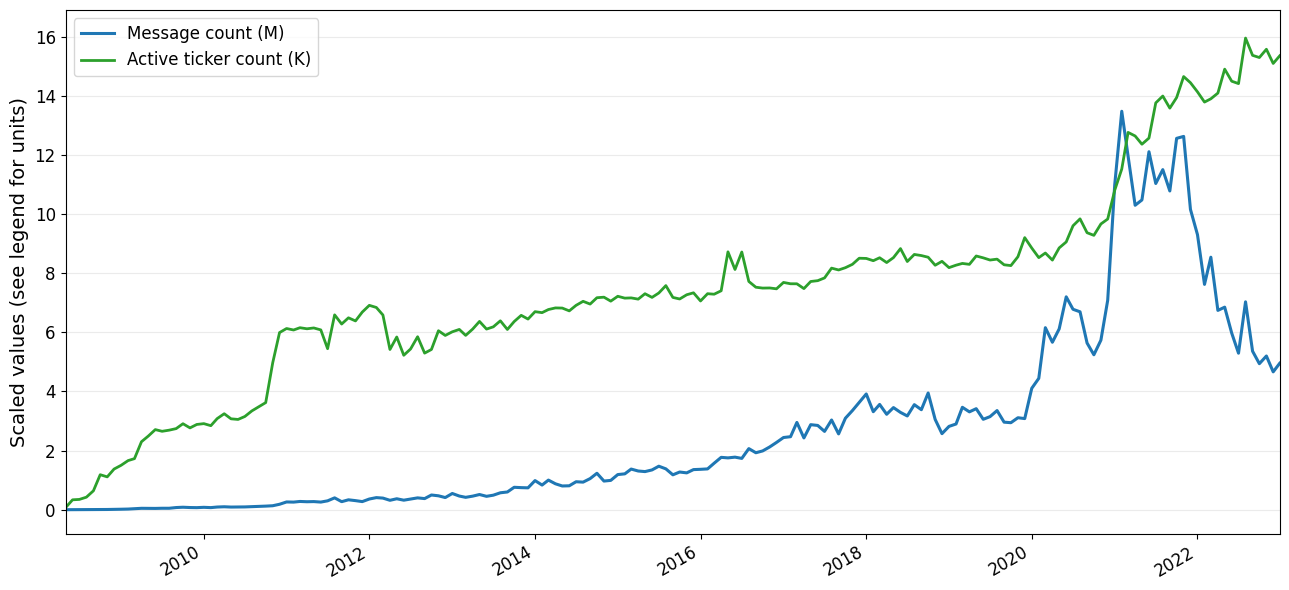

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

plot_end = pd.Timestamp("2022-12-31")
plot_start = monthly_overview["month"].min()

message_color = "#1f77b4"
ticker_color = "#2ca02c"

fig, ax = plt.subplots(figsize=(13, 6))

# Scale data
message_scaled = monthly_overview["message_count"] / 1_000_000   # millions
ticker_scaled = monthly_overview["active_ticker_count"] / 1_000  # thousands

# Plot
ax.plot(
    monthly_overview["month"],
    message_scaled,
    color=message_color,
    linewidth=2.2,
    label="Message count (M)",
)

ax.plot(
    monthly_overview["month"],
    ticker_scaled,
    color=ticker_color,
    linewidth=2.0,
    label="Active ticker count (K)",
)

# Labels (bigger)
ax.set_xlabel("", fontsize=14)
ax.set_ylabel("Scaled values (see legend for units)", fontsize=14)

# Tick label size (important for readability)
ax.tick_params(axis="both", labelsize=12)

# Grid and limits
ax.grid(True, axis="y", alpha=0.25)
ax.set_xlim(plot_start, plot_end)

# Legend (also slightly bigger)
ax.legend(loc="upper left", fontsize=12)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [8]:
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
monthly_overview.to_csv(OUTPUT_CSV, index=False, date_format="%Y-%m-%d")
print(f"Saved monthly overview data to: {OUTPUT_CSV.resolve()}")

Saved monthly overview data to: C:\stocktwits_2026\stocktwits_worldmodel\figure_making\data\1_a_monthly_overview.csv


In [14]:
DATA_ROOT = Path(r"C:\stocktwits_2026\parquet\feature_wo_messages")

year_dirs = sorted(
    [path for path in DATA_ROOT.glob("year=*") if path.is_dir()],
    key=lambda path: int(path.name.split("=", 1)[1]),
)

selected_year_dirs = [
    path for path in year_dirs
    if int(path.name.split("=", 1)[1]) <= 2022
]

selected_files = [
    parquet_file
    for year_dir in selected_year_dirs
    for parquet_file in sorted(year_dir.glob("month=*/*.parquet"))
]

print(f"Dataset root: {DATA_ROOT}")
print(f"Selected year partitions (<= 2022): {[path.name for path in selected_year_dirs]}")
print(f"Selected parquet files: {len(selected_files):,}")

if not selected_files:
    raise FileNotFoundError("No parquet files found for years up to and including 2022.")

Dataset root: C:\stocktwits_2026\parquet\feature_wo_messages
Selected year partitions (<= 2022): ['year=2008', 'year=2009', 'year=2010', 'year=2011', 'year=2012', 'year=2013', 'year=2014', 'year=2015', 'year=2016', 'year=2017', 'year=2018', 'year=2019', 'year=2020', 'year=2021', 'year=2022']
Selected parquet files: 1,202


In [15]:
sample_file = selected_files[0]
print(f"Sample parquet file: {sample_file}")

if BACKEND == "duckdb":
    con = duckdb.connect()
    schema_df = con.execute(
        f"DESCRIBE SELECT * FROM read_parquet('{sample_file.as_posix()}', hive_partitioning = true)"
    ).df()[["column_name", "column_type"]]
    schema_df = schema_df.rename(columns={"column_name": "column", "column_type": "dtype"})
else:
    parquet_schema = pq.ParquetFile(sample_file).schema_arrow
    schema_df = pd.DataFrame({
        "column": parquet_schema.names,
        "dtype": [str(parquet_schema.field(name).type) for name in parquet_schema.names],
    })

print(schema_df.to_string(index=False))

columns = set(schema_df["column"])

required_columns = {"message_id", "user_id", "created_at", "symbol_list"}
missing_schema_columns = sorted(required_columns - columns)
if missing_schema_columns:
    raise RuntimeError(
        f"Missing expected columns: {missing_schema_columns}"
    )

DATE_COLUMN = "created_at"
USER_COLUMN = "user_id"
MESSAGE_COLUMN = "message_id"
TICKER_COLUMN = "symbol_list"

Sample parquet file: C:\stocktwits_2026\parquet\feature_wo_messages\year=2008\month=10\part.0.parquet
                column                    dtype
            message_id                  VARCHAR
               user_id                   DOUBLE
            created_at TIMESTAMP WITH TIME ZONE
             sentiment                  VARCHAR
     parent_message_id                  VARCHAR
in_reply_to_message_id                  VARCHAR
           symbol_list                  VARCHAR
                 month                   BIGINT
                  year                   BIGINT


In [16]:
if BACKEND == "duckdb":
    parquet_glob = (DATA_ROOT / "year=*" / "month=*" / "*.parquet").as_posix()

    count_df = con.execute(f"""
        WITH base AS (
            SELECT
                {MESSAGE_COLUMN} AS message_id,
                {DATE_COLUMN} AS created_at,
                {TICKER_COLUMN} AS symbol_list,
                regexp_extract_all({TICKER_COLUMN}, '''([^'']+)''', 1) AS ticker_array
            FROM read_parquet('{parquet_glob}', hive_partitioning = true)
            WHERE year <= 2022
        ),
        flags AS (
            SELECT
                *,
                array_length(ticker_array) AS ticker_count
            FROM base
        )
        SELECT
            COUNT(*) AS total_messages,
            SUM(CASE WHEN ticker_count >= 1 THEN 1 ELSE 0 END) AS ticker_messages
        FROM flags
    """).df()

else:
    dataset = ds.dataset(DATA_ROOT, format="parquet", partitioning="hive")
    filter_expression = ds.field("year") <= 2022

    total_messages = 0
    ticker_messages = 0

    for batch in dataset.to_batches(
        columns=[MESSAGE_COLUMN, TICKER_COLUMN],
        filter=filter_expression,
        batch_size=250_000,
    ):
        batch_df = batch.to_pandas()
        total_messages += len(batch_df)

        ticker_count = batch_df[TICKER_COLUMN].fillna("").astype(str).apply(
            lambda x: len(literal_eval(x)) if x.strip().startswith("[") and x.strip().endswith("]") else 0
        )
        ticker_messages += (ticker_count >= 1).sum()

    count_df = pd.DataFrame([{
        "total_messages": total_messages,
        "ticker_messages": ticker_messages
    }])

count_df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_messages,ticker_messages
0,464446946,241198362.0


In [17]:
total_n = int(count_df.loc[0, "total_messages"])
ticker_n = int(count_df.loc[0, "ticker_messages"])

print(f"Total messages: {total_n:,}")
print(f"Messages with ticker: {ticker_n:,}")
print(f"Share with ticker: {ticker_n / total_n:.2%}")

Total messages: 464,446,946
Messages with ticker: 241,198,362
Share with ticker: 51.93%


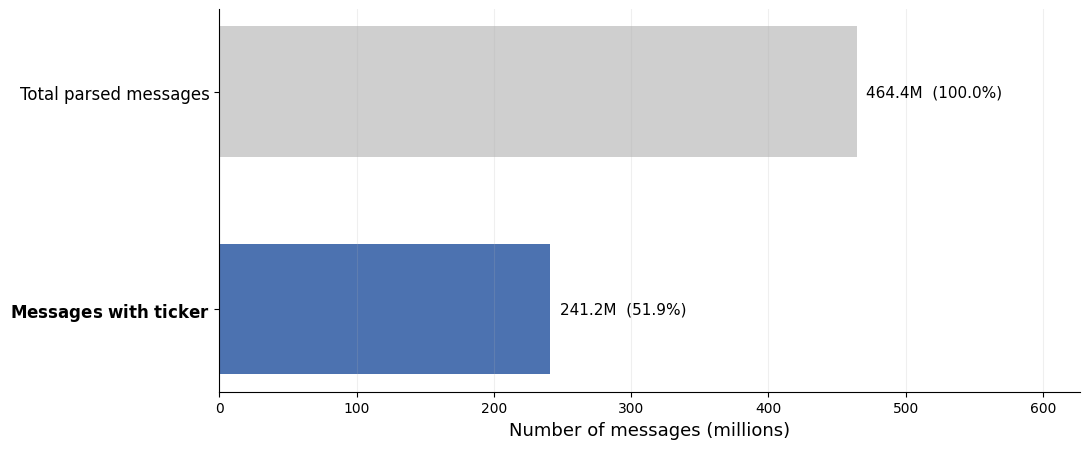

In [20]:
import numpy as np
from matplotlib.ticker import FuncFormatter
stages = [
    "Total parsed messages",
    r"$\bf{Messages\ with\ ticker}$"
]

counts = np.array([total_n, ticker_n])
pct_total = counts / counts[0]

fig, ax = plt.subplots(figsize=(11, 4.6))
y = np.arange(len(stages))

ax.barh(y[0], counts[0], height=0.6, color="#CFCFCF")
ax.barh(y[1], counts[1], height=0.6, color="#4C72B0")

ax.set_yticks(y)
ax.set_yticklabels(stages, fontsize=12)
ax.invert_yaxis()

ax.set_xlabel("Number of messages (millions)", fontsize=13)
ax.set_xlim(0, counts[0] * 1.35)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.0f}"))

for i, value in enumerate(counts):
    ax.text(
        value + counts[0] * 0.015,
        y[i],
        f"{value/1e6:.1f}M  ({pct_total[i]:.1%})",
        va="center",
        fontsize=11
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

In [24]:
if BACKEND == "duckdb":
    monthly_counts = con.execute(f"""
        WITH base AS (
            SELECT
                {DATE_COLUMN} AS created_at,
                regexp_extract_all({TICKER_COLUMN}, '''([^'']+)''', 1) AS ticker_array
            FROM read_parquet('{parquet_glob}', hive_partitioning = true)
            WHERE year <= 2022
        )
        SELECT
            date_trunc('month', CAST(created_at AS TIMESTAMP)) AS month,
            COUNT(*) AS n_messages
        FROM base
        WHERE array_length(ticker_array) >= 1
        GROUP BY 1
        ORDER BY 1
    """).df()

else:
    dataset = ds.dataset(DATA_ROOT, format="parquet", partitioning="hive")
    filter_expression = ds.field("year") <= 2022

    monthly_chunks = []

    for batch in dataset.to_batches(
        columns=[DATE_COLUMN, TICKER_COLUMN],
        filter=filter_expression,
        batch_size=250_000,
    ):
        batch_df = batch.to_pandas()
        batch_df[TICKER_COLUMN] = batch_df[TICKER_COLUMN].fillna("").astype(str)

        batch_df["ticker_count"] = batch_df[TICKER_COLUMN].apply(
            lambda x: len(literal_eval(x)) if x.strip().startswith("[") and x.strip().endswith("]") else 0
        )

        batch_df = batch_df[batch_df["ticker_count"] >= 1].copy()
        batch_df["month"] = pd.to_datetime(batch_df[DATE_COLUMN]).dt.to_period("M").dt.to_timestamp()

        monthly_chunks.append(
            batch_df.groupby("month").size().rename("n_messages")
        )

    monthly_counts = (
        pd.concat(monthly_chunks, axis=0)
        .groupby(level=0)
        .sum()
        .reset_index()
    )

monthly_counts["month"] = pd.to_datetime(monthly_counts["month"])
monthly_counts.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,n_messages
0,2008-05-01,70
1,2008-06-01,707
2,2008-07-01,860
3,2008-08-01,1017
4,2008-09-01,3258


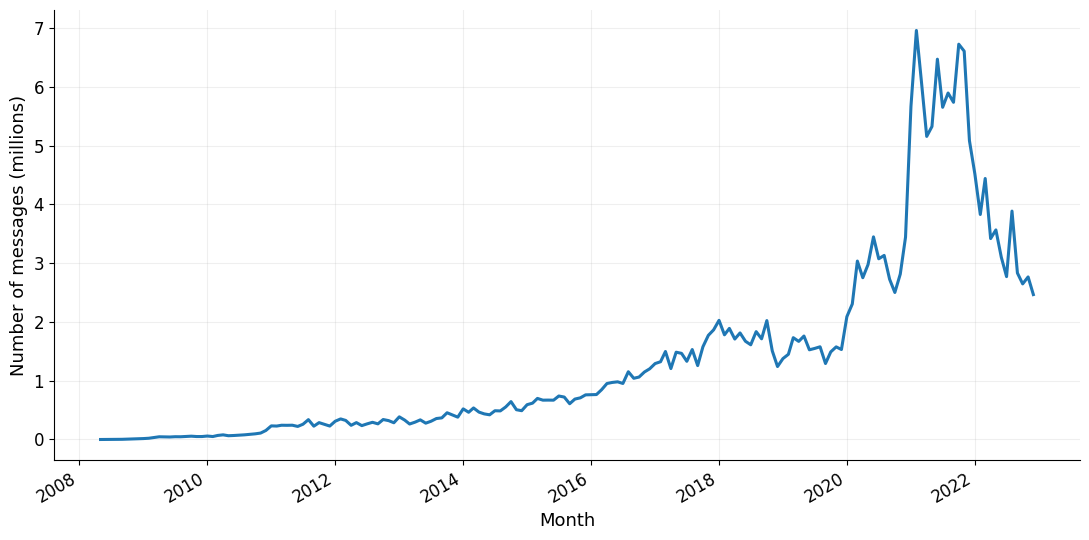

In [25]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    monthly_counts["month"],
    monthly_counts["n_messages"] / 1_000_000,
    linewidth=2.2,
    color="#1f77b4"
)

ax.set_xlabel("Month", fontsize=13)
ax.set_ylabel("Number of messages (millions)", fontsize=13)

ax.tick_params(axis="both", labelsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.2)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [26]:
if BACKEND == "duckdb":
    ticker_counts = con.execute(f"""
        WITH base AS (
            SELECT
                regexp_extract_all({TICKER_COLUMN}, '''([^'']+)''', 1) AS ticker_array
            FROM read_parquet('{parquet_glob}', hive_partitioning = true)
            WHERE year <= 2022
        ),
        exploded AS (
            SELECT UNNEST(ticker_array) AS ticker
            FROM base
            WHERE array_length(ticker_array) >= 1
        )
        SELECT
            ticker,
            COUNT(*) AS n_messages
        FROM exploded
        WHERE ticker IS NOT NULL
          AND trim(ticker) <> ''
        GROUP BY 1
        ORDER BY n_messages DESC
    """).df()

else:
    dataset = ds.dataset(DATA_ROOT, format="parquet", partitioning="hive")
    filter_expression = ds.field("year") <= 2022

    from collections import Counter
    ticker_counter = Counter()

    for batch in dataset.to_batches(
        columns=[TICKER_COLUMN],
        filter=filter_expression,
        batch_size=250_000,
    ):
        batch_df = batch.to_pandas()
        for raw in batch_df[TICKER_COLUMN].fillna("").astype(str):
            try:
                tickers = literal_eval(raw) if raw.strip().startswith("[") else []
            except Exception:
                tickers = []
            for t in tickers:
                t = str(t).strip().upper()
                if t:
                    ticker_counter[t] += 1

    ticker_counts = (
        pd.DataFrame(ticker_counter.items(), columns=["ticker", "n_messages"])
        .sort_values("n_messages", ascending=False)
        .reset_index(drop=True)
    )

ticker_counts.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,ticker,n_messages
0,SPY,12686163
1,AMC,8473650
2,TSLA,4934602
3,AAPL,4575771
4,BTC.X,4097376


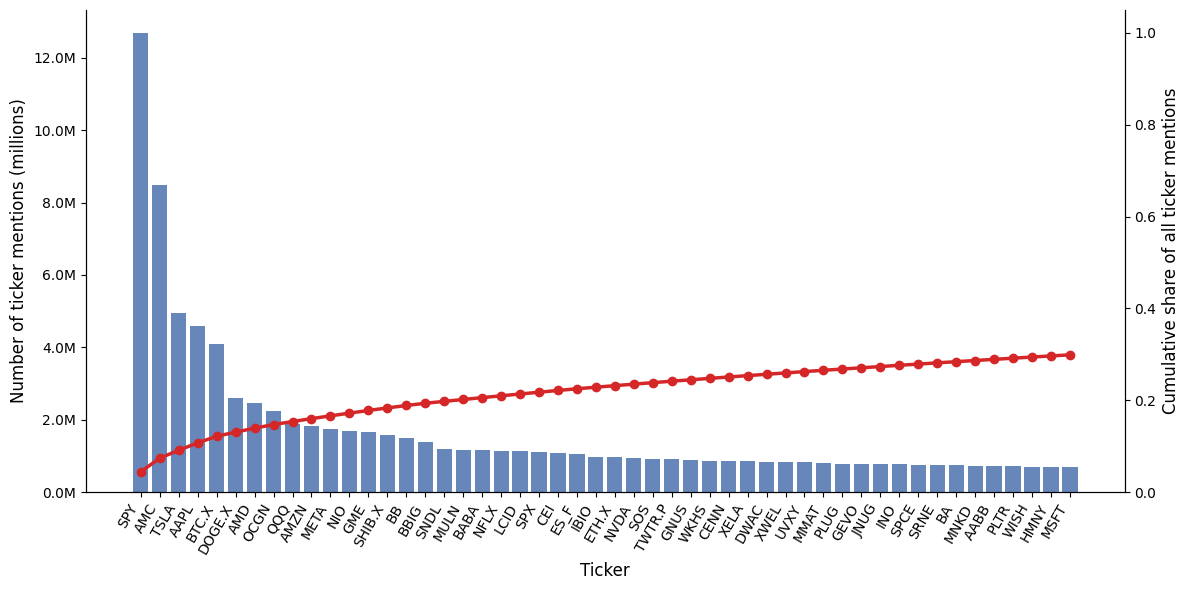

In [27]:
top_n = 50

plot_df = ticker_counts.head(top_n).copy()
plot_df["cum_share"] = plot_df["n_messages"].cumsum() / ticker_counts["n_messages"].sum()

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_df))

ax1.bar(x, plot_df["n_messages"], alpha=0.85, color="#4C72B0")

ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["ticker"], rotation=60, ha="right")

ax1.set_ylabel("Number of ticker mentions (millions)", fontsize=12)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y/1e6:.1f}M"))
ax1.set_xlabel("Ticker", fontsize=12)

ax1.spines["top"].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(
    x,
    plot_df["cum_share"],
    marker="o",
    linewidth=2.5,
    color="#D62728"
)

ax2.set_ylabel("Cumulative share of all ticker mentions", fontsize=12)
ax2.set_ylim(0, 1.05)

ax2.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

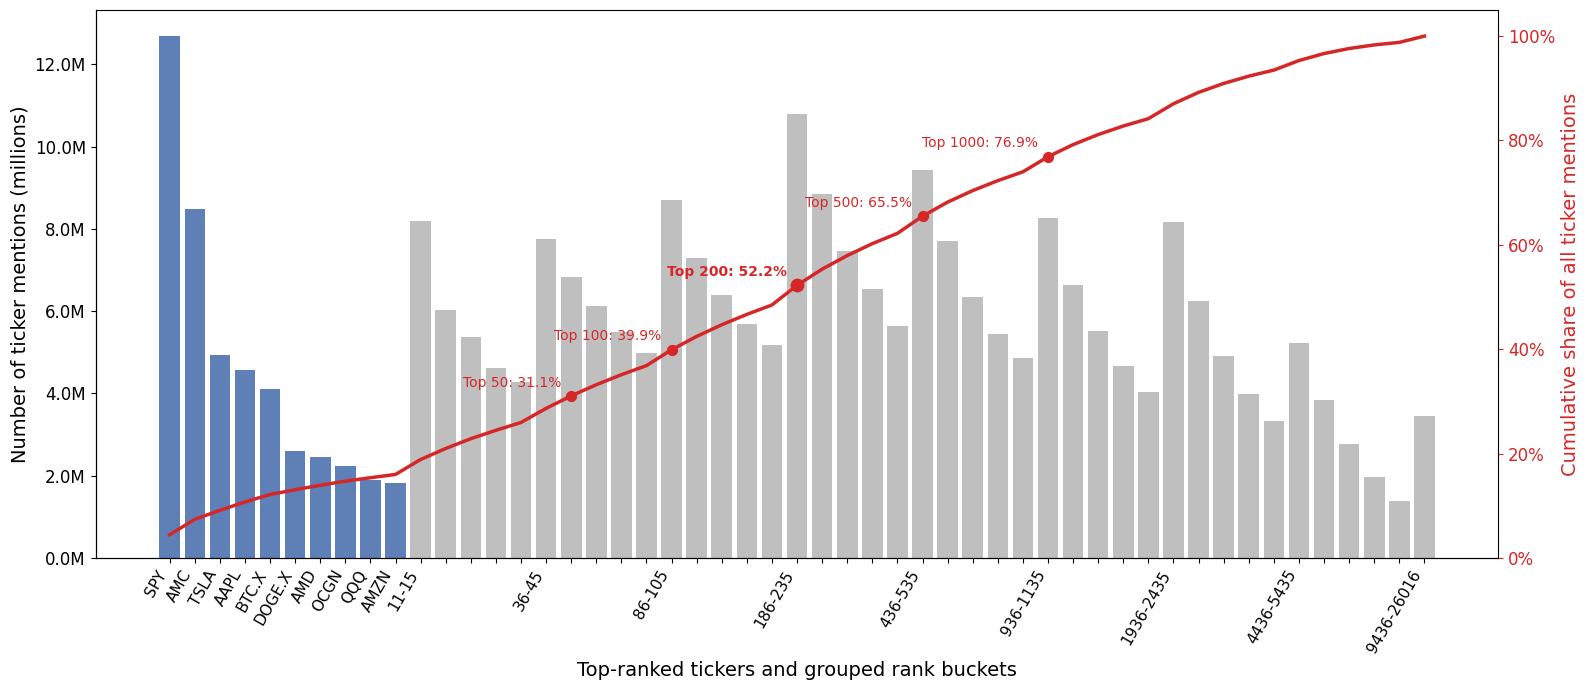

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, PercentFormatter

# =========================================================
# Sort ticker counts
# ticker_counts should have columns: ['ticker', 'n_messages']
# where n_messages = number of ticker-containing messages mentioning that ticker
# =========================================================

ticker_counts_sorted = (
    ticker_counts.sort_values("n_messages", ascending=False)
    .reset_index(drop=True)
    .copy()
)

total_messages_all = ticker_counts_sorted["n_messages"].sum()
n_tickers = len(ticker_counts_sorted)

# =========================================================
# Build hybrid bins:
# - top 10 shown individually
# - then grouped rank buckets with increasing width
# =========================================================

rows = []

# --- top 10 individually ---
n_head = min(10, n_tickers)
for i in range(n_head):
    rows.append({
        "label": ticker_counts_sorted.loc[i, "ticker"],
        "messages": ticker_counts_sorted.loc[i, "n_messages"],
        "start_rank": i + 1,
        "end_rank": i + 1,
        "width": 1
    })

# --- grouped buckets ---
current_start = n_head + 1
width_sequence = [5, 10, 20, 50, 100, 200, 500, 1000]

for width in width_sequence:
    for _ in range(5):
        if current_start > n_tickers:
            break

        current_end = min(current_start + width - 1, n_tickers)
        bucket_df = ticker_counts_sorted.iloc[current_start - 1: current_end]

        rows.append({
            "label": f"{current_start}-{current_end}",
            "messages": bucket_df["n_messages"].sum(),
            "start_rank": current_start,
            "end_rank": current_end,
            "width": width
        })

        current_start = current_end + 1

# --- final tail bucket ---
if current_start <= n_tickers:
    bucket_df = ticker_counts_sorted.iloc[current_start - 1: n_tickers]

    rows.append({
        "label": f"{current_start}+",
        "messages": bucket_df["n_messages"].sum(),
        "start_rank": current_start,
        "end_rank": n_tickers,
        "width": "tail"
    })

plot_df = pd.DataFrame(rows)
plot_df["cum_messages"] = plot_df["messages"].cumsum()
plot_df["cum_share"] = plot_df["cum_messages"] / total_messages_all

# =========================================================
# Plot
# =========================================================

fig, ax1 = plt.subplots(figsize=(16, 7))
x = np.arange(len(plot_df))

# Bars: highlight top 10, gray for grouped buckets
bar_colors = ["#4C72B0" if i < n_head else "#B8B8B8" for i in range(len(plot_df))]
ax1.bar(x, plot_df["messages"], color=bar_colors, alpha=0.9, width=0.82)

# Show only first label of each bucket-width regime
display_labels = []
prev_width = None

for i, row in plot_df.iterrows():
    if i < n_head:
        display_labels.append(row["label"])
    else:
        if row["width"] != prev_width:
            display_labels.append(f"{row['start_rank']}-{row['end_rank']}")
        else:
            display_labels.append("")
        prev_width = row["width"]

ax1.set_xticks(x)
ax1.set_xticklabels(display_labels, rotation=60, ha="right", fontsize=11)

ax1.set_ylabel("Number of ticker mentions (millions)", fontsize=14)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y/1e6:.1f}M"))

ax1.set_xlabel("Top-ranked tickers and grouped rank buckets", fontsize=14)
ax1.tick_params(axis="y", labelsize=12)
ax1.tick_params(axis="x", labelsize=11)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# =========================================================
# Cumulative concentration line
# =========================================================

ax2 = ax1.twinx()
ax2.plot(
    x,
    plot_df["cum_share"],
    color="#D62728",
    linewidth=2.5
)

ax2.set_ylabel("Cumulative share of all ticker mentions", fontsize=14, color="#D62728")
ax2.tick_params(axis="y", colors="#D62728", labelsize=12)
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.spines["top"].set_visible(True)

# =========================================================
# Mark key cutoffs
# =========================================================

for ref_rank in [50, 100, 200, 500, 1000]:
    candidates = plot_df.index[plot_df["end_rank"] >= ref_rank]
    if len(candidates) == 0:
        continue

    idx = candidates[0]
    share = plot_df.loc[idx, "cum_share"]

    if ref_rank == 200:
        marker_size = 80
        fw = "bold"
        dx = -0.4
    else:
        marker_size = 50
        fw = "normal"
        dx = -0.4

    ax2.scatter(idx, share, color="#D62728", s=marker_size, zorder=6)

    ax2.text(
        idx + dx,
        share + 0.012,
        f"Top {ref_rank}: {share:.1%}",
        ha="right",
        va="bottom",
        fontsize=10,
        color="#D62728",
        fontweight=fw
    )

plt.tight_layout()
plt.show()